# Experimental Analysis Notebook

This notebook analyzes data collected from an optical see-through AR pseudo-haptic experiment.  
The experiment investigates whether visual deformation alone can support a pseudo-haptic perception of softness during interaction with a virtual soft ball.

The analysis includes:
- loading and merging CSV files exported from the Unity prototype;
- checking participant and trial consistency;
- analyzing subjective ratings across three visual deformation gain levels;
- summarizing post-questionnaire responses;
- analyzing perceived visual disconnection;
- applying an exploratory Friedman test to compare rating differences across gain levels.

Tracking-derived metrics are interpreted as interaction checks, not as physical force measurements.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Consistent plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150

In [ ]:
# Load and merge CSV files

# Project paths
project_root = Path("..")
data_dir = project_root / "data" / "raw"
plots_dir = project_root / "plots"

plots_dir.mkdir(parents=True, exist_ok=True)

# Load CSV files
csv_files = sorted(data_dir.glob("*.csv"))

dataframes = []

for index, file in enumerate(csv_files, start=1):
    df = pd.read_csv(file, sep=";")
    
    # Keep the original Unity ID only for traceability
    df["unity_participant_id"] = df["participant_id"]
    
    # Assign a clean participant ID based on file order
    df["participant_id"] = index
    
    # Save the source file name
    df["source_file"] = file.name
    
    dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

participant_summary = data.groupby("participant_id").agg(
    source_file=("source_file", "first"),
    n_pre=("phase", lambda x: (x == "pre").sum()),
    n_trials=("phase", lambda x: (x == "trial").sum()),
    n_post=("phase", lambda x: (x == "post").sum())
).reset_index()

print("\nCSV uploaded")
participant_summary

,participant_id,source_file,n_pre,n_trials,n_post
0,1,CogAR_test_P01_20260617_103601.csv,2,6,9
1,2,CogAR_test_P02_20260617_105000.csv,2,6,9
2,3,CogAR_test_P03_20260617_105906.csv,2,6,9
3,4,CogAR_test_P04_20260618_125338.csv,2,6,9
4,5,CogAR_test_P05_20260618_130111.csv,2,6,9
5,6,CogAR_test_P06_20260618_130706.csv,2,6,8
6,7,CogAR_test_P07_20260618_133138.csv,2,6,8
7,8,CogAR_test_P08_20260618_133912.csv,2,6,9
8,9,CogAR_test_P09_20260618_144125.csv,2,6,9
9,10,CogAR_test_P10_20260618_144825.csv,2,6,9


## Prepare data
In this section, we extract the data from the CSV files and divide it into three categories:
1. pre-data: the data related to calibration and the user (dominant hand and experience with AR);
2. trial-data: the data related to the experiments, that is, those linked to the interaction with the ball;
3. post-data: the data extracted from the questionnaires after the soft ball tests.

In [ ]:
# Convert numeric columns
numeric_columns = [
    "participant_id",
    "unity_participant_id",
    "trial_index",
    "gain",
    "rating",
    "max_squeeze",
    "mean_squeeze",
    "max_thumb_pressure",
    "mean_thumb_pressure"
]

for column in numeric_columns:
    if column in data.columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")

# Split data into experimental phases
trial_data = data[data["phase"] == "trial"].copy()
pre_data = data[data["phase"] == "pre"].copy()
post_data = data[data["phase"] == "post"].copy()

### Data check
Each CSV file corresponds to one participant.  
Participant IDs were reassigned during loading to ensure unique anonymized identifiers across files.  
The following table checks that each participant has the expected number of pre-questionnaire rows, trial rows, and post-questionnaire rows.

In [ ]:
# Check data consistency
participants_count = trial_data["participant_id"].nunique()
trial_count = len(trial_data)

print("Number of participants:", participants_count)
print("Number of trial rows:", trial_count)
print("Expected trial rows:", participants_count * 6)

trial_data.groupby("participant_id")["trial_index"].count()

Number of participants: 13
Number of trial rows: 78
Expected trial rows: 78


participant_id
1     6
2     6
3     6
4     6
5     6
6     6
7     6
8     6
9     6
10    6
11    6
12    6
13    6
Name: trial_index, dtype: int64

### Participant-level trial ratings

Each participant completed two trials for each visual gain level.  
For the main analysis, the two repetitions were averaged so that each participant contributes one mean rating for each condition: low, medium, and high.

In [ ]:
# Average the two repetitions so that each participant contributes one value per condition.
gain_order = ["low", "medium", "high"]

participant_gain_means = trial_data.groupby(
    ["participant_id", "gain_label"]
)["rating"].mean().reset_index()

participant_gain_means["gain_label"] = pd.Categorical(
    participant_gain_means["gain_label"],
    categories=gain_order,
    ordered=True
)

participant_gain_means = participant_gain_means.sort_values(
    ["participant_id", "gain_label"]
)

print("\nAverage contributes for every user")
participant_gain_means.head()

,participant_id,gain_label,rating
1,1,low,6.0
2,1,medium,7.0
0,1,high,6.5
4,2,low,4.5
5,2,medium,4.0


## Participants Overview
Before the trials, participant-level information was summarized.  
For each participant, we considered the dominant hand and the previous experience with Augmented Reality.  
This step was used only to describe the sample and not to perform statistical comparisons between groups.

In [ ]:
# Participant information summary
participant_col = "participant_id"
question_col = "question_id"
rating_col = "rating"

participant_questions = [
    "handedness",
    "ar_vr_familiarity"
]

# Select only the pre-experiment participant information
participant_info_raw = pre_data[
    pre_data[question_col].isin(participant_questions)
].copy()

# Convert ratings to numeric values
participant_info_raw[rating_col] = pd.to_numeric(
    participant_info_raw[rating_col],
    errors="coerce"
)

# Create one row per participant
participant_info = participant_info_raw.pivot_table(
    index=participant_col,
    columns=question_col,
    values=rating_col,
    aggfunc="first"
).reset_index()

# Remove the column index name created by pivot_table
participant_info.columns.name = None

# Convert questionnaire values to integer format
participant_info["handedness"] = participant_info["handedness"].astype("Int64")
participant_info["ar_vr_familiarity"] = participant_info["ar_vr_familiarity"].astype("Int64")

# Mapping used for the Unity questionnaire
dominant_hand_map = {
    1: "Right-handed",
    2: "Left-handed",
    3: "Ambidextrous"
}

ar_experience_map = {
    1: "No previous AR experience",
    2: "Low AR experience",
    3: "Moderate-low AR experience",
    4: "Medium AR experience",
    5: "Moderate-high AR experience",
    6: "High AR experience",
    7: "Very high AR experience"
}

# Add readable labels
participant_info["dominant_hand"] = participant_info["handedness"].map(dominant_hand_map)
participant_info["ar_experience_level"] = participant_info["ar_vr_familiarity"].map(ar_experience_map)

# Create summary tables
dominant_hand_summary = (
    participant_info["dominant_hand"]
    .value_counts(dropna=False)
    .rename_axis("Category")
    .reset_index(name="Count")
)

dominant_hand_summary["Variable"] = "Dominant hand"

ar_experience_summary = (
    participant_info["ar_experience_level"]
    .value_counts(dropna=False)
    .rename_axis("Category")
    .reset_index(name="Count")
)

ar_experience_summary["Variable"] = "Previous AR experience"

participant_summary_table = pd.concat(
    [
        dominant_hand_summary,
        ar_experience_summary
    ],
    ignore_index=True
)

participant_summary_table = participant_summary_table[
    [
        "Variable",
        "Category",
        "Count"
    ]
]

print("\nParticipant information")
participant_summary_table

,Variable,Category,Count
0,Dominant hand,Right-handed,11
1,Dominant hand,Left-handed,2
2,Previous AR experience,Low AR experience,5
3,Previous AR experience,No previous AR experience,4
4,Previous AR experience,High AR experience,2
5,Previous AR experience,Very high AR experience,1
6,Previous AR experience,Moderate-high AR experience,1


## Analysis

### Subjective deformation clarity by visual gain

The main dependent variable is the subjective rating of deformation clarity, collected after each trial on a 1–7 scale.  
The independent variable is the visual deformation gain, with three levels: low, medium, and high.

This analysis tests whether higher visual deformation gain is associated with higher perceived deformation clarity.

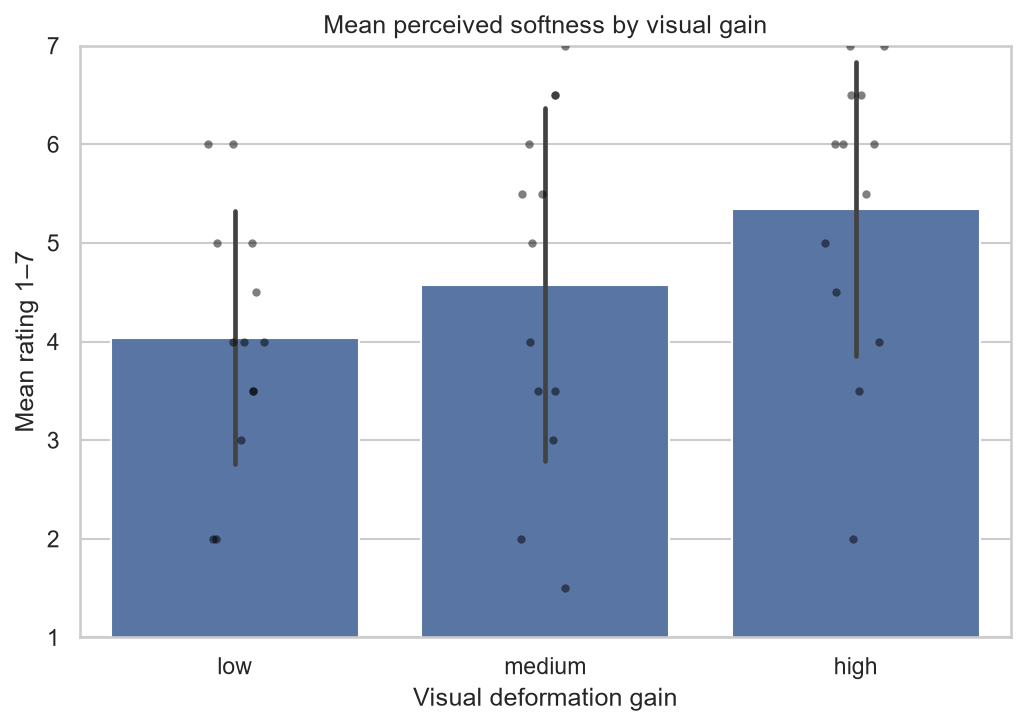

In [ ]:
# Apply ordered categorical to trial_data 
trial_data["gain_label"] = pd.Categorical(
    trial_data["gain_label"],
    categories=gain_order,
    ordered=True
)

# Plot perceived deformation clarity by visual gain using participant-level means
# Bars show means ± SD; individual participant means are overlaid as dots
plt.figure(figsize=(7, 5))

sns.barplot(
    data=participant_gain_means,
    x="gain_label",
    y="rating",
    order=gain_order,
    errorbar="sd"
)

sns.stripplot(
    data=participant_gain_means,
    x="gain_label",
    y="rating",
    order=gain_order,
    color="black",
    alpha=0.5,
    jitter=True,
    size=4
)

plt.title("Mean perceived softness by visual gain")
plt.xlabel("Visual deformation gain")
plt.ylabel("Mean rating 1–7")
plt.ylim(1, 7)
plt.tight_layout()

plt.savefig(plots_dir / "perceived_deformation_clarity_by_gain_sd.png", dpi=300)
plt.show()

The plot shows mean participant-level ratings for each visual gain condition.  
Error bars represent standard deviation across this ratings.
Individual participant means are overlaid as dots; some points extend beyond the error bars, reflecting the natural variability across participants within each condition.

The descriptive trend indicates that perceived deformation clarity increases from low to medium and high visual gain levels.

### Tracking-derived interaction metrics

This section logs tracking-derived measures of interaction intensity.  
The variable `max_squeeze` is interpreted as a palm-based compression estimate, while `max_thumb_pressure` is interpreted as a thumb contact estimate.

These values do not represent physical force or real pressure. They are used only as interaction checks to verify that participants performed the intended gesture during the trials.

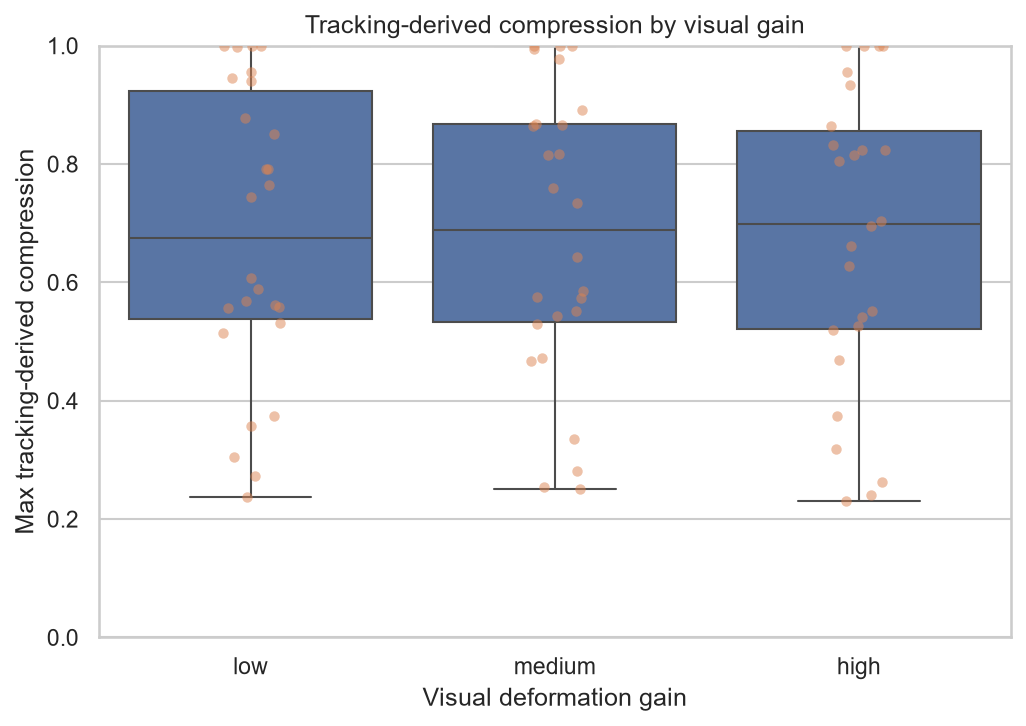

In [ ]:
# Tracking-derived compression estimate
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=trial_data,
    x="gain_label",
    y="max_squeeze",
    order=gain_order
)

sns.stripplot(
    data=trial_data,
    x="gain_label",
    y="max_squeeze",
    order=gain_order,
    alpha=0.5,
    jitter=True
)

plt.title("Tracking-derived compression by visual gain")
plt.xlabel("Visual deformation gain")
plt.ylabel("Max tracking-derived compression")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(plots_dir / "compression_by_gain_boxplot.png", dpi=300)
plt.show()

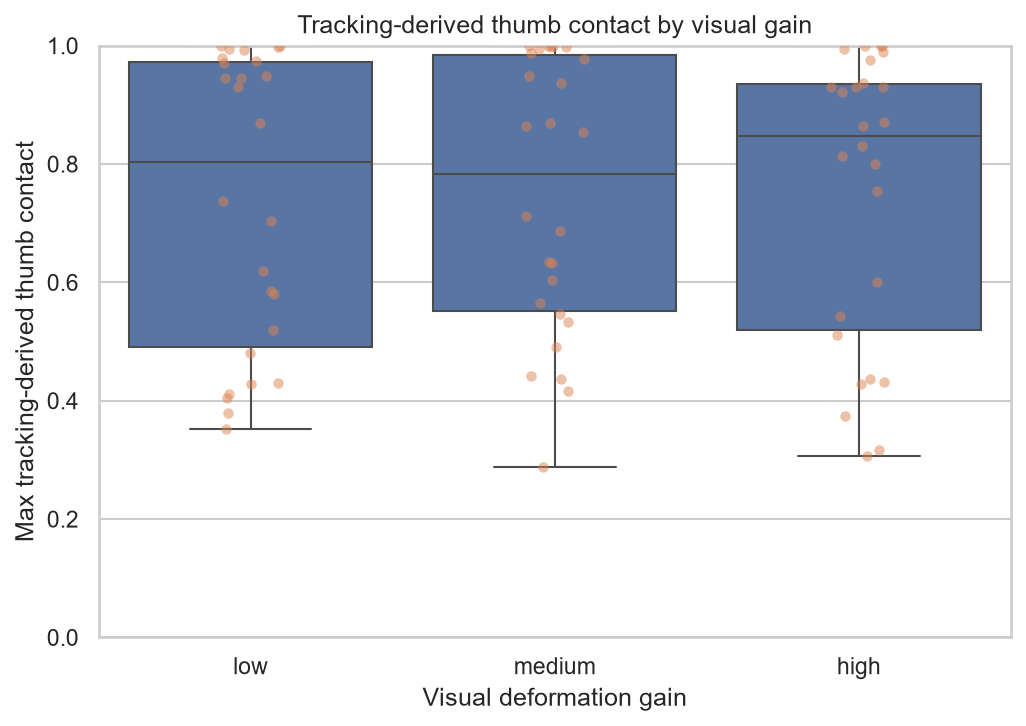

In [ ]:
# Tracking-derived THUMB contact
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=trial_data,
    x="gain_label",
    y="max_thumb_pressure",
    order=gain_order
)

sns.stripplot(
    data=trial_data,
    x="gain_label",
    y="max_thumb_pressure",
    order=gain_order,
    alpha=0.5,
    jitter=True
)

plt.title("Tracking-derived thumb contact by visual gain")
plt.xlabel("Visual deformation gain")
plt.ylabel("Max tracking-derived thumb contact")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(plots_dir / "thumb_contact_by_gain_boxplot.png", dpi=300)
plt.show()

The medians seem to be more or less similar in all cases, so the three conditions have similar values. Therefore we could consider small differences between the conditions.

The participants interacted with the ball in a fairly comparable manner between low, medium, and high. It is possible to consider the increase in ratings can be interpreted as an effect of visual distortion.

## Post-questionnaire analysis

The post-questionnaire was used to evaluate the overall subjective quality of the interaction after the trial sequence.  
Questions measured perceived softness, elasticity, contact believability, visual touch influence, movement match, object-like perception, and the contribution of the thumb.

The disconnection questions are analyzed separately because they are categorical rather than 1–7 scale ratings.

In [ ]:
# Considering post data
post_scale_questions = [
    "perceived softness",
    "elasticity",
    "contact_believability",
    "thumb_contribution",
    "visual_touch_influence",
    "object_vs_animation",
    "movement_match"
]

post_scale_data = post_data[
    post_data["question_id"].isin(post_scale_questions)
].copy()

post_scale_summary = post_scale_data.groupby("question_id").agg(
    mean_rating=("rating", "mean"),
    std_rating=("rating", "std"),
    count=("rating", "count")
).reset_index()

post_scale_summary = post_scale_summary.sort_values(
    "mean_rating",
    ascending=True
)

print("\nOrdering data with respect to the mean rating")
post_scale_summary

,question_id,mean_rating,std_rating,count
4,thumb_contribution,3.769231,2.047513,13
0,contact_believability,4.076923,1.656379,13
5,visual_touch_influence,4.230769,1.640825,13
1,elasticity,4.307692,1.315587,13
2,movement_match,4.384615,1.260850,13
3,object_vs_animation,5.153846,1.463224,13


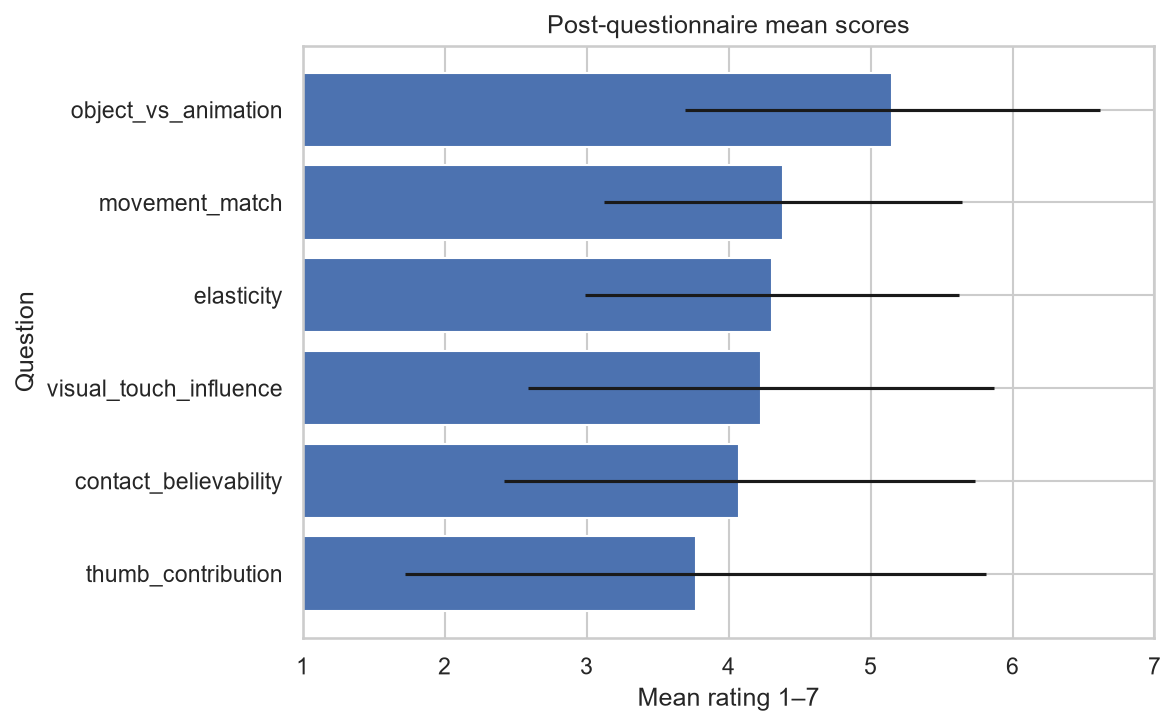

In [ ]:
# Plotting post-experiment scale ratings
# softness: how soft the ball felt
# elasticity: how elastic the ball felt
# contact_believability: how believable the contact felt
# visual_touch_influence: how much the visual deformation created a sense of contact
# object_vs_animation: whether it felt more like an interactive object or just an animation
# movement_match: how well the deformation followed the hand movement
# thumb_contribution: how much the thumb improved the interaction

plt.figure(figsize=(8, 5))

plt.barh(
    post_scale_summary["question_id"],
    post_scale_summary["mean_rating"],
    xerr=post_scale_summary["std_rating"]
)

plt.title("Post-questionnaire mean scores")
plt.xlabel("Mean rating 1–7")
plt.ylabel("Question")
plt.xlim(1, 7)
plt.tight_layout()

plt.savefig(plots_dir / "post_questionnaire_horizontal.png", dpi=300)
plt.show()

### Thumb Contribution and Visual Disconnection
This section analyzes the role of the thumb in the interaction.  
The goal is to understand whether adding the thumb made the interaction more convincing or whether it introduced a critical point for the pseudo-haptic illusion.

The analysis is based on two post-questionnaire elements:

- `thumb_contribution`: how much adding the thumb made the interaction feel more convincing.
- `disconnection_presence` and `disconnection_timing`: whether the participant perceived a visual-motor disconnection and when it occurred.

This is a descriptive analysis. It does not represent a real before/after comparison, because the experiment did not collect separate ratings before and after adding the thumb.

#### Thumb contribution

In [ ]:
# This section evaluates whether the thumb improved the interaction or created a critical point.
participant_col = "participant_id"
question_col = "question_id"
rating_col = "rating"

thumb_question_id = "thumb_contribution"
disconnection_presence_id = "disconnection_presence"
disconnection_timing_id = "disconnection_timing"

# Thumb contribution
thumb_data = post_data[
    post_data[question_col] == thumb_question_id
].copy()

thumb_data[rating_col] = pd.to_numeric(
    thumb_data[rating_col],
    errors="coerce"
)

thumb_summary = pd.DataFrame({
    "Measure": ["N", "Mean", "SD", "Median", "Min", "Max"],
    "Value": [
        thumb_data[rating_col].count(),
        thumb_data[rating_col].mean(),
        thumb_data[rating_col].std(),
        thumb_data[rating_col].median(),
        thumb_data[rating_col].min(),
        thumb_data[rating_col].max()
    ]
})

print("Thumb contribution rating")
display(thumb_summary)

# Categorize thumb contribution
# 1-3 = low contribution, 4 = neutral, 5-7 = high contribution
def categorize_thumb_rating(value):
    if pd.isna(value):
        return "Missing"
    if value <= 3:
        return "Low contribution"
    if value == 4:
        return "Neutral"
    return "High contribution"

thumb_data["thumb_contribution_category"] = thumb_data[rating_col].apply(
    categorize_thumb_rating
)

thumb_category_summary = (
    thumb_data["thumb_contribution_category"]
    .value_counts(dropna=False)
    .rename_axis("Thumb contribution category")
    .reset_index(name="Count")
)

print("\nThumb contribution categories")
display(thumb_category_summary)

Thumb contribution rating


,Measure,Value
0,N,13.000000
1,Mean,3.769231
2,SD,2.047513
3,Median,3.000000
4,Min,1.000000
5,Max,7.000000



Thumb contribution categories


,Thumb contribution category,Count
0,Low contribution,7
1,High contribution,5
2,Neutral,1


#### Disconnection
Participants were asked whether they perceived any visual-disconnection during the interaction.  
If they answered yes, they were asked to indicate when the disconnection first occurred.

This analysis is useful to identify which part of the interaction was most critical for the pseudo-haptic illusion.

In [ ]:
# Disconnection
disconnection_data = post_data[
    post_data[question_col] == disconnection_presence_id
].copy()

disconnection_summary = (
    disconnection_data["binary_answer"]
    .value_counts(dropna=False)
    .rename_axis("Reported disconnection")
    .reset_index(name="Count")
)

disconnection_summary["Percentage"] = (
    disconnection_summary["Count"] / disconnection_summary["Count"].sum() * 100
).round(1)

print("Reported visual-motor disconnection")
display(disconnection_summary)

Reported visual-motor disconnection


,Reported disconnection,Count,Percentage
0,yes,9,69.2
1,no,4,30.8


In [ ]:
# Disconnection timing
disconnection_timing = post_data[
    post_data[question_col] == disconnection_timing_id
].copy()

disconnection_timing[rating_col] = pd.to_numeric(
    disconnection_timing[rating_col],
    errors="coerce"
)

timing_labels = {
    1: "From the beginning",
    2: "First contact",
    3: "Adding the thumb",
    4: "Toward the end"
}

disconnection_timing["timing_label"] = disconnection_timing[rating_col].map(
    timing_labels
)

timing_summary = (
    disconnection_timing["timing_label"]
    .value_counts(dropna=False)
    .rename_axis("Moment of disconnection")
    .reset_index(name="Count")
)

timing_summary["Percentage among disconnections"] = (
    timing_summary["Count"] / timing_summary["Count"].sum() * 100
).round(1)

print("Timing of perceived disconnection")
display(timing_summary)

Timing of perceived disconnection


,Moment of disconnection,Count,Percentage among disconnections
0,Adding the thumb,6,66.7
1,From the beginning,2,22.2
2,First contact,1,11.1


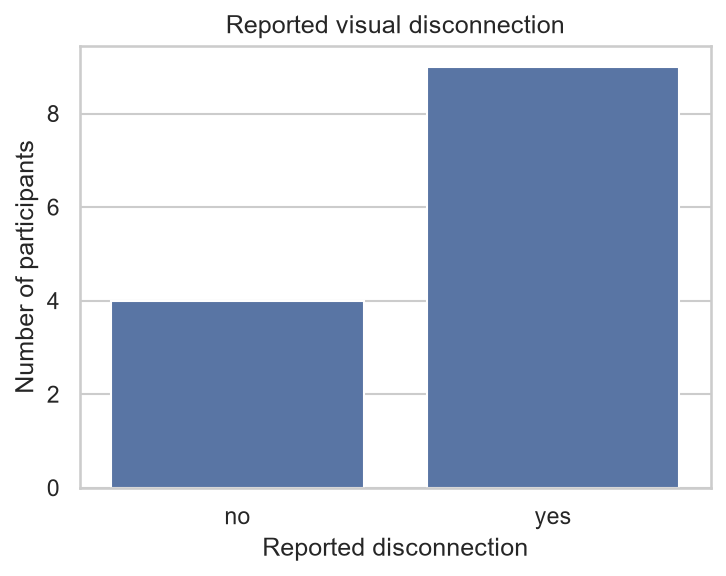

In [ ]:
# Plot
plt.figure(figsize=(5, 4))

sns.countplot(
    data=disconnection_data,
    x="binary_answer",
    order=["no", "yes"]
)

plt.title("Reported visual disconnection")
plt.xlabel("Reported disconnection")
plt.ylabel("Number of participants")
plt.tight_layout()

plt.savefig(plots_dir / "disconnection_presence_count.png", dpi=300)
plt.show()

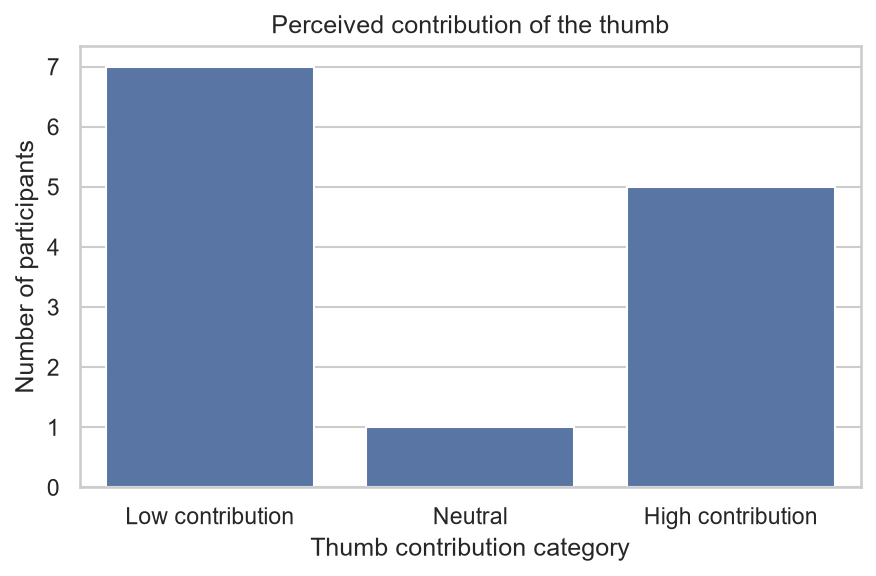

In [ ]:
# Plot thumb contribution categories

plt.figure(figsize=(6, 4))

sns.countplot(
    data=thumb_data,
    x="thumb_contribution_category",
    order=["Low contribution", "Neutral", "High contribution"]
)

plt.title("Perceived contribution of the thumb")
plt.xlabel("Thumb contribution category")
plt.ylabel("Number of participants")
plt.tight_layout()

plt.savefig(plots_dir / "thumb_contribution_categories.png", dpi=300)
plt.show()

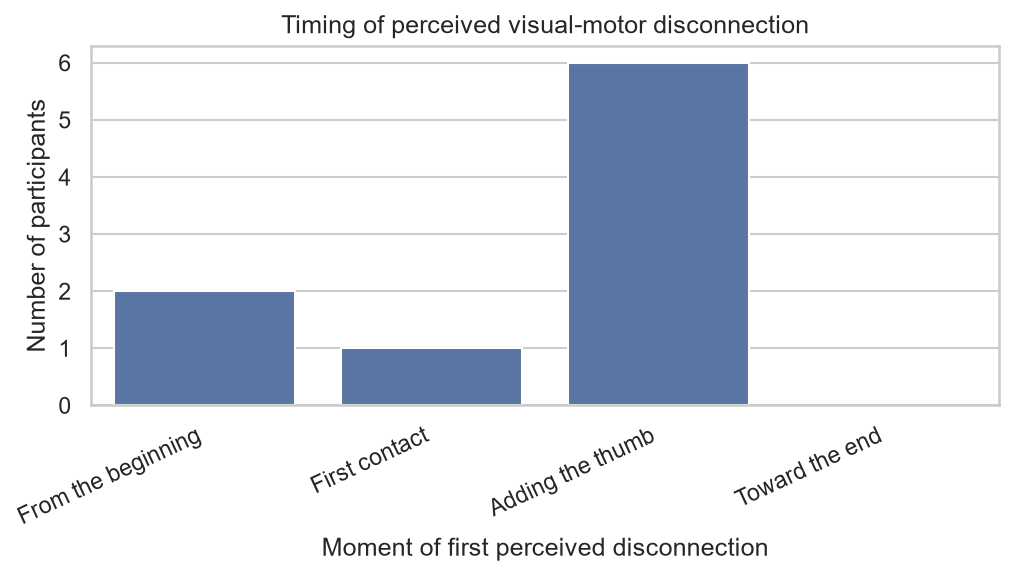

In [ ]:
# Plot timing of disconnection

timing_order = [
    "From the beginning",
    "First contact",
    "Adding the thumb",
    "Toward the end"
]

plt.figure(figsize=(7, 4))

sns.countplot(
    data=disconnection_timing,
    x="timing_label",
    order=timing_order
)

plt.title("Timing of perceived visual-motor disconnection")
plt.xlabel("Moment of first perceived disconnection")
plt.ylabel("Number of participants")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(plots_dir / "disconnection_timing.png", dpi=300)
plt.show()

The thumb was intended to make the interaction more similar to a natural squeeze. However, the questionnaire and disconnection analysis suggest that the thumb also represented a critical point for the illusion. This is probably because the thumb introduced a stronger expectation of physical contact, but the AR setup could not provide a real spatial or physical constraint to stop the hand.

### Statistical analysis
A **Friedman test** was used to compare perceived deformation clarity across the three visual gain levels.

This test was selected because the experiment follows a within-subject design: each participant experienced all three gain levels. Since ratings were collected on a 1–7 Likert scale and the sample size is limited, a non-parametric repeated-measures test is appropriate.

The Friedman test evaluates whether there is a statistically significant difference among the three conditions, but it does not identify which specific pairs differ.

In [ ]:
# Create a participant x condition table for the Friedman test
friedman_pivot = participant_gain_means.pivot(
    index="participant_id",
    columns="gain_label",
    values="rating"
)

friedman_pivot = friedman_pivot[["low", "medium", "high"]].dropna()

display(friedman_pivot)

friedman_result = stats.friedmanchisquare(
    friedman_pivot["low"],
    friedman_pivot["medium"],
    friedman_pivot["high"]
)

n_participants = len(friedman_pivot)
n_conditions = 3

# Kendall's W effect size for Friedman test
kendalls_w = friedman_result.statistic / (n_participants * (n_conditions - 1))

print("Number of participants included:", n_participants)
print("Friedman statistic:", round(friedman_result.statistic, 3))
print("p-value:", round(friedman_result.pvalue, 4))
print("Kendall's W:", round(kendalls_w, 3))

if friedman_result.pvalue < 0.05:
    print("Result: significant difference across visual gain levels.")
else:
    print("Result: no statistically significant difference across visual gain levels.")

gain_label,low,medium,high
participant_id,,,
1,6.0,7.0,6.5
2,4.5,4.0,4.5
3,6.0,6.5,6.0
4,5.0,3.5,6.0
5,4.0,5.0,6.0
6,4.0,6.5,7.0
7,5.0,6.0,7.0
8,2.0,2.0,3.5
9,3.5,3.5,5.0


Number of participants included: 13
Friedman statistic: 11.911
p-value: 0.0026
Kendall's W: 0.458
Result: significant difference across visual gain levels.


Evaluating all participants together, the differences between low, medium, and high are consistent enough to be considered significant (p-value = 0.0026).

To identify which conditions differed from each other, post-hoc **Wilcoxon matched-pairs signed-rank tests** were performed. This test was selected because each comparison involved paired ratings from the same participants. A **Bonferroni** correction was applied to account for the three pairwise comparisons:
- low vs medium
- medium vs high
- low vs high

In [ ]:
# Post-hoc pairwise Wilcoxon matched-pairs tests with Bonferroni correction

comparisons = [
    ("low", "medium"),
    ("medium", "high"),
    ("low", "high")
]

posthoc_results = []
n = len(friedman_pivot)

for condition_a, condition_b in comparisons:
    result = stats.wilcoxon(
        friedman_pivot[condition_a],
        friedman_pivot[condition_b],
        zero_method="wilcox",
        alternative="two-sided"
    )

    # Effect size r = |Z| / sqrt(N)
    z_score = stats.norm.ppf(result.pvalue / 2)
    effect_size_r = abs(z_score) / np.sqrt(n)

    posthoc_results.append({
        "comparison": f"{condition_a} vs {condition_b}",
        "wilcoxon_statistic": result.statistic,
        "p_uncorrected": result.pvalue,
        "effect_size_r": round(effect_size_r, 3)
    })

posthoc_df = pd.DataFrame(posthoc_results)

# Bonferroni correction for three comparisons
number_of_comparisons = len(comparisons)

posthoc_df["p_bonferroni"] = (
    posthoc_df["p_uncorrected"] * number_of_comparisons
).clip(upper=1.0)

posthoc_df["significant_after_bonferroni"] = posthoc_df["p_bonferroni"] < 0.05

posthoc_df

,comparison,wilcoxon_statistic,p_uncorrected,effect_size_r,p_bonferroni,significant_after_bonferroni
0,low vs medium,11.5,0.105469,0.449,0.316406,False
1,medium vs high,6.0,0.007812,0.738,0.023438,True
2,low vs high,0.0,0.001953,0.859,0.005859,True


After Bonferroni correction, two out of three pairwise comparisons remained significant: medium vs high and low vs high. The low vs medium comparison was not significant. This suggests that the *high visual gain condition* was perceived as different from the other two conditions.

In [ ]:
# Export CSV per JASP statistical analysis
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

export_df = friedman_pivot.reset_index()
export_df.columns.name = None

export_path = processed_dir / "participant_gain_means_for_jasp_r.csv"

export_df.to_csv(
    export_path,
    sep=";",
    decimal=".",
    index=False,
    encoding="utf-8-sig"
)

print(f"File exported to: {export_path}")

File exported to: ..\data\processed\participant_gain_means_for_jasp_r.csv


To validate the Python statistical analysis, the dataset was exported as a processed CSV file and analyzed in JASP. The JASP analysis replicated the main non-parametric repeated-measures approach using a Friedman test.

The test confirmed a significant effect of deformation gain on perceived deformation clarity, $\chi^2(2) = 11.91$, $p = .003$. Kendall's $W = 0.458$ suggests that this effect was not negligible.
JASP also provided Conover's post-hoc comparisons, which showed the same pattern observed in Python with the Bonferroni correction: the high-gain condition differed from both the low and medium conditions, while the low vs medium comparison was not significant.

This confirms that the main result is consistent across the Python and JASP analyses.

JASP also ran a repeated measures ANOVA by default, but given the Likert-scale nature of the ratings and the limited sample size (N = 13), the non-parametric Friedman test is the more appropriate choice and is retained as the primary analysis.

## Summary of findings
Overall, the descriptive results suggest that subjective ratings increased from low to medium and high visual deformation gain. This indicates that participants were able to perceive differences between the three deformation levels.

Post-questionnaire results suggest that the virtual ball was generally perceived as a responsive and soft object rather than as a simple animation. However, the thumb contribution received lower scores compared to other dimensions, suggesting that the thumb-based component of the interaction was less convincing and represents a limitation of the current prototype.

The disconnection analysis further supports this interpretation, as several participants reported visual-motor disconnection when the thumb was added to the interaction.

Tracking-derived metrics were used as interaction checks and should not be interpreted as physical force or pressure measurements.

Given the pilot nature of the study, the results should be interpreted as preliminary evidence that visual deformation can support pseudo-haptic perception of softness in optical see-through AR.